# Appendix A: Discretization Exploration

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import gymnasium as gym

from collections import defaultdict

from tqdm import tqdm
from joblib import Parallel, delayed

from src.logger import LogManager


In [2]:
manager = LogManager()

main_log = manager.get_logger("Main", "discretization.log")

In [3]:
env = gym.make("Acrobot-v1", render_mode = "rgb_array")
state = env.reset(seed = 42)

main_log.info("--- New Session Started ---")
main_log.info(f"Environment: Acrobot-v1")
main_log.info(f"Initial State: {state}")
main_log.info(f"State Space: {env.observation_space}")
main_log.info(f"Action Space: {env.action_space}")

2026-04-17 16:07:58 | INFO    | --- New Session Started ---
2026-04-17 16:07:58 | INFO    | Environment: Acrobot-v1
2026-04-17 16:07:58 | INFO    | Initial State: (array([ 0.99849933,  0.0547638 ,  0.99992526, -0.01222401,  0.07171959,
        0.0394736 ], dtype=float32), {})
2026-04-17 16:07:58 | INFO    | State Space: Box([ -1.        -1.        -1.        -1.       -12.566371 -28.274334], [ 1.        1.        1.        1.       12.566371 28.274334], (6,), float32)
2026-04-17 16:07:58 | INFO    | Action Space: Discrete(3)


In [4]:
ANGLE_BINS = 8
VEL_BINS = 6

LOW = np.array([-np.pi, -np.pi, -6, -10])
HIGH = np.array([ np.pi,  np.pi,  6,  10])
BINS = np.array([ANGLE_BINS, ANGLE_BINS, VEL_BINS, VEL_BINS])

def transform_state(obs):
    cos1, sin1, cos2, sin2, w1, w2 = obs
    
    theta1 = np.arctan2(sin1, cos1)
    theta2 = np.arctan2(sin2, cos2)
    
    return np.array([theta1, theta2, w1, w2])

def discretise(obs):
    state = transform_state(obs)
    
    ratios = (state - LOW) / (HIGH - LOW)
    ratios = np.clip(ratios, 0, 1)
    
    discrete = (ratios * (BINS - 1)).astype(int)
    return tuple(discrete)

In [5]:
main_log.info(f"Discretization Bins: {BINS}")

2026-04-17 16:07:58 | INFO    | Discretization Bins: [8 8 6 6]


## 1. Notebook Utilities

In [6]:
def select_action(policy, state, mode="greedy", epsilon=0.05, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    if isinstance(policy[state], np.ndarray):  # Q-table
        if mode == "greedy":
            return np.argmax(policy[state])
        elif mode == "epsilon_greedy":
            if rng.random() < epsilon:
                return rng.integers(len(policy[state]))
            return np.argmax(policy[state])

    else:  # probability policy (REINFORCE)
        probs = policy[state]
        if mode == "greedy":
            return np.argmax(probs)
        elif mode == "stochastic":
            return rng.choice(len(probs), p=probs)
        elif mode == "epsilon_greedy":
            if rng.random() < epsilon:
                return rng.integers(len(probs))
            return np.argmax(probs)

In [7]:
def evaluate_policy(policy, n_episodes=20, mode="greedy", seed=42):
    env = gym.make("Acrobot-v1")
    rng = np.random.default_rng(seed)

    rewards = []
    steps = []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed = seed + ep)
        state = discretise(obs)

        done = False
        total_reward = 0
        t = 0

        while not done:
            action = select_action(policy, state, mode = mode, rng = rng)
            obs, reward, term, trunc, _ = env.step(action)

            state = discretise(obs)
            total_reward += reward
            t += 1
            done = term or trunc

        rewards.append(total_reward)
        steps.append(t)

    return {
        "mean_reward": np.mean(rewards),
        "std_reward": np.std(rewards),
        "mean_steps": np.mean(steps),
        "success_rate": np.mean(np.array(steps) < 500)
    }

In [8]:
def record_episode(policy, filename, mode="greedy"):
    env = gym.make("Acrobot-v1", render_mode="rgb_array")
    frames = []

    obs, _ = env.reset(seed = 42)
    state = discretise(obs)

    done = False

    while not done:
        frames.append(env.render())
        action = select_action(policy, state, mode=mode)
        obs, reward, term, trunc, _ = env.step(action)

        state = discretise(obs)
        done = term or trunc

    imageio.mimsave(filename, frames, fps=50)

In [9]:
def run_experiment(algorithm_func, name, params):
    main_log.info(f"Starting Experiment: {name}")
    main_log.info(f"Hyperparameters: {params}")

    params["seed"] = 42
    params["n_episodes"] = 1000

    # ---------------- TRAIN ----------------
    model, rewards = algorithm_func(env, params=params)

    main_log.info(f"{name} Training Completed")

    # ---------------- SAVE ----------------
    save_policy(model, name)

    # ---------------- EVALUATE ----------------
    eval_greedy = evaluate_policy(model, mode="greedy")

    main_log.info(f"{name} Evaluation (Greedy): {eval_greedy}")

    print("\n=== EVALUATION ===")
    print("Greedy:", eval_greedy)

    # ---------------- PLOTS ----------------
    plot_learning_curve(rewards, name)
    plot_smoothed_learning_curve(rewards, name)

    # ---------------- RECORD ----------------
    record_episode(model, f"results/{name}.gif", mode="greedy")

    return model, rewards, {
        "greedy": eval_greedy,
    }

In [10]:
def alg_SARSA(env, params):
    """
    SARSA implementation.
    """

    # Configuration parameters
    seed = params["seed"]
    rng = np.random.default_rng(seed)
    
    # Problem-specific parameters
    n_episodes = params["n_episodes"]
    n_actions = env.action_space.n
    
    gamma = params["gamma"]
    epsilon = params["epsilon"]
    epsilon_min = params["epsilon_min"]
    
    # Algorithm-specific parameters
    alpha = params["alpha"]
    epsilon_decay = params["epsilon_decay"]

    # --- Initialization ---
    
    Q = defaultdict(lambda: np.zeros(n_actions))
    rewards_history = []

    for ep in tqdm(range(n_episodes), desc = "Training SARSA"):
        obs, _ = env.reset(seed = seed)
        state = discretise(obs)
        action = select_action(
            policy = Q, 
            state = state, 
            mode = "epsilon_greedy", 
            epsilon = epsilon, 
            rng = rng
        )

        total_reward = 0
        done = False

        while not done:
            next_obs, reward, term, trunc, _ = env.step(action)
            next_state = discretise(next_obs)
            
            next_action = select_action(
                policy = Q, 
                state = state, 
                mode = "epsilon_greedy", 
                epsilon = epsilon, 
                rng = rng
            )

            Q[state][action] += alpha * (reward + gamma * Q[next_state][next_action] - Q[state][action])

            state, action = next_state, next_action
            total_reward += reward
            done = term or trunc

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards_history.append(total_reward)

    return Q, rewards_history

In [11]:
# --- HYPERPARAMETERS ---
# These parameters are SARSA / Q-learning specific. 

SARSA_PARAMS = {
    # Problem parameters: <- Fixed parameters to the given problem
    "n_episodes": 1000,
    "gamma": 0.99,
    "epsilon": 1.0,
    "epsilon_min": 0.05,

    # Config parameters: <- Display and Robustness testing
    "seed": 42,
    "show_progress": False,

    # Algorithm parameters: <- Parameters optimized for robust algorithms
    "alpha": 0.15,
    "epsilon_decay": 0.99,
}

In [12]:
discretization_results = []

main_log.info(f"STARTING DISCRETIZATION SEARCH")
params = SARSA_PARAMS.copy()

def run_discretization_trial(ab, vb, seed, params):
    global BINS
    BINS = np.array([ab, ab, vb, vb])
    
    main_log.info(f"Testing bins: ANGLE={ab}, VEL={vb}, SEED={seed}")
    params_copy = params.copy()
    params_copy["seed"] = seed
    
    Q, rewards = alg_SARSA(env, params_copy)
    eval_metrics = evaluate_policy(Q)
    
    return {
        "angle_bins": ab,
        "vel_bins": vb,
        "seed": seed,
        **eval_metrics
    }

trials = [(ab, vb, seed) for ab in [6, 8, 10, 12, 16] for vb in [6, 8, 10, 12, 16] for seed in range(3)]

discretization_results = []
with tqdm(total=len(trials), desc="Discretization Search") as pbar:
    for result in Parallel(n_jobs=-1, return_as='generator')(
        delayed(run_discretization_trial)(ab, vb, seed, params) for ab, vb, seed in trials
    ):
        discretization_results.append(result)
        pbar.update(1)

2026-04-17 16:07:58 | INFO    | STARTING DISCRETIZATION SEARCH


Discretization Search: 100%|██████████| 75/75 [28:19<00:00, 22.66s/it]  


In [18]:
df = pd.DataFrame(discretization_results)
df.sort_values('mean_reward')

,angle_bins,vel_bins,seed,mean_reward,std_reward,mean_steps,success_rate
0,6,6,0,-500.00,0.000000,500.00,0.00
1,6,6,1,-500.00,0.000000,500.00,0.00
2,6,6,2,-500.00,0.000000,500.00,0.00
7,6,10,1,-500.00,0.000000,500.00,0.00
9,6,12,0,-500.00,0.000000,500.00,0.00
...,...,...,...,...,...,...,...
35,10,8,2,-294.60,113.513171,295.45,0.85
18,8,8,0,-293.90,83.067382,294.90,1.00
38,10,10,2,-289.60,120.843866,290.45,0.85
39,10,12,0,-273.95,113.801351,274.90,0.95


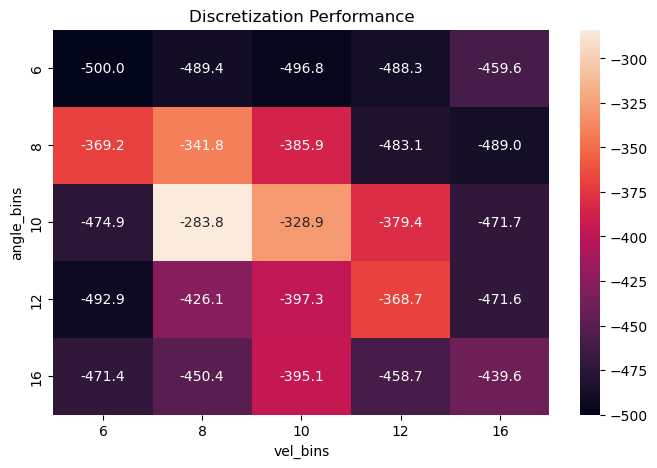

In [19]:
plt.figure(figsize=(8,5))
sns.heatmap(
    df.groupby(by=['angle_bins', 'vel_bins'])['mean_reward'].mean().unstack(),
    annot=True,
    fmt=".1f"
)
plt.title("Discretization Performance")
plt.show()

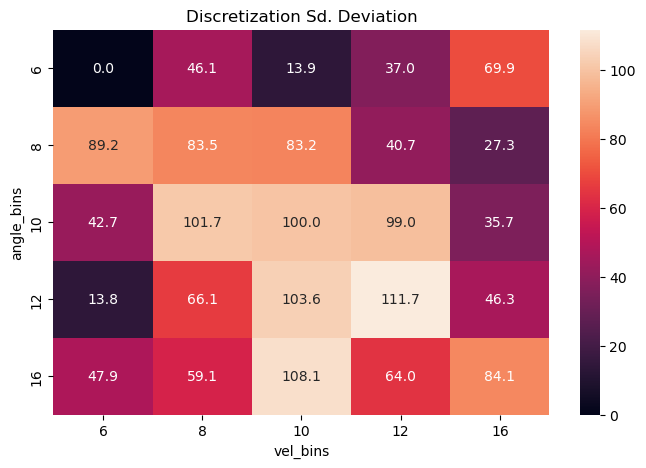

In [20]:
plt.figure(figsize=(8,5))
sns.heatmap(
    df.groupby(by=['angle_bins', 'vel_bins'])['std_reward'].mean().unstack(),
    annot=True,
    fmt=".1f"
)
plt.title("Discretization Sd. Deviation")
plt.show()

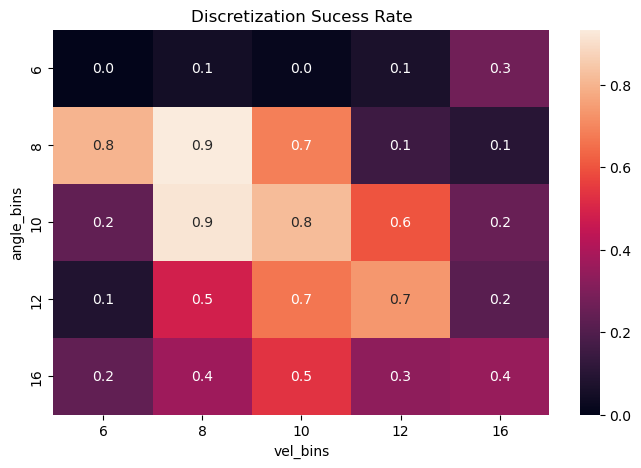

In [21]:
plt.figure(figsize=(8,5))
sns.heatmap(
    df.groupby(by=['angle_bins', 'vel_bins'])['success_rate'].mean().unstack(),
    annot=True,
    fmt=".1f"
)
plt.title("Discretization Sucess Rate")
plt.show()